## Convolution (Lab2)
All of examples are given by Prof. Sinan Xiao from Shien-Ming Wu School of Intelligent Engineering, SCUT Spring 2026 
 
 V3nt1_onthemic organized the lab content and summarized it, adapting the original MATLAB teaching materials to Python for signal and system applications and exercises

### SYLLABUS:

Understand the mechanism of convolution and its application in obtaining the output signals from an LTI system.

### OBJECT:

Write a Python program to obtain convolution of the given signals by developing your own functions and using the built-in function, respectively.


## THEORY:

Convolution is a mathematical operation used to express the relation between input and output of an LTI system. It relates input, output and impulse response of an LTI system as:

$$ y(t) = x(t) * h(t) \qquad (1.1) $$

Where \( y(t) \) = output of LTI, \( x(t) \) = input of LTI, \( h(t) \) = impulse response of LTI.

There are two types of convolutions:

### a) Continuous Convolution

$$ y(t) = x(t) * h(t) = \int_{-\infty}^{\infty} x(\tau) \, h(t - \tau) \, d\tau \qquad (1.2) $$

### b) Discrete Convolution

$$ y(n) = x(n) * h(n) = \sum_{k = -\infty}^{\infty} x(k) \, h(n - k) \qquad (1.3) $$

### EXPERIMENT 1: Write functions to calculate the continuous-time (CT) and discrete-time (DT) convolution, respectively (not using the built-in conv function in MATLAB)

This experiment is to develop two functions using MATLAB to calculate the CT and DT convolution, respectively. Try to develop the functions based on the equations (1.2) and (1.3), and use the given input signals and impulse response to examine your developed functions:

#### (1) Discrete-Time Convolution

Develop a function for discrete-time convolution to calculate the response of a discrete-time LTI system with an impulse response \( h[n] \) to an input signal \( x[n] \). The discrete-time LTI system has the following unit-impulse response:

$$ h[n] = 2^n, \qquad 0 \leq n \leq 6 $$

##### (a)
Calculate the response of this system to:

$$ x_1[n] = 1, \qquad 0 \leq n \leq 4 $$

and plot the response.

##### (b)
Calculate the response of this system to:

$$ x_2[n] = 2, \qquad 3 \leq n \leq 6 $$

and plot the response.

##### (c)
Calculate the response of this system to:

$$ x_3[n] = x_1[n] + x_2[n] $$

and plot the response.
#### (2) Continuous-Time Convolution

Develop a function for continuous-time convolution to calculate the response of a continuous-time LTI system with an impulse response \( h(t) \) to an input signal \( x(t) \). The continuous-time LTI system has the following unit-impulse response:

$$ h(t) = u(t) $$

##### (a)
Calculate the response of this system to:

$$ x_1(t) = e^{-2t} u(t) $$

and plot the response.

##### (b)
Calculate the response of this system to:

$$ x_2(t) = u(t - 1) - u(t - 3) $$

and plot the response.

##### (c)
Calculate the response of this system to:

$$ x_3(t) = x_1(t) + x_2(t) $$

and plot the response.

实验 1: 离散卷积
y1 长度: 11, n_y1 范围: 0~10
y2 长度: 10, n_y2 范围: 0~9
y3 长度: 13, n_y3 范围: 0~12


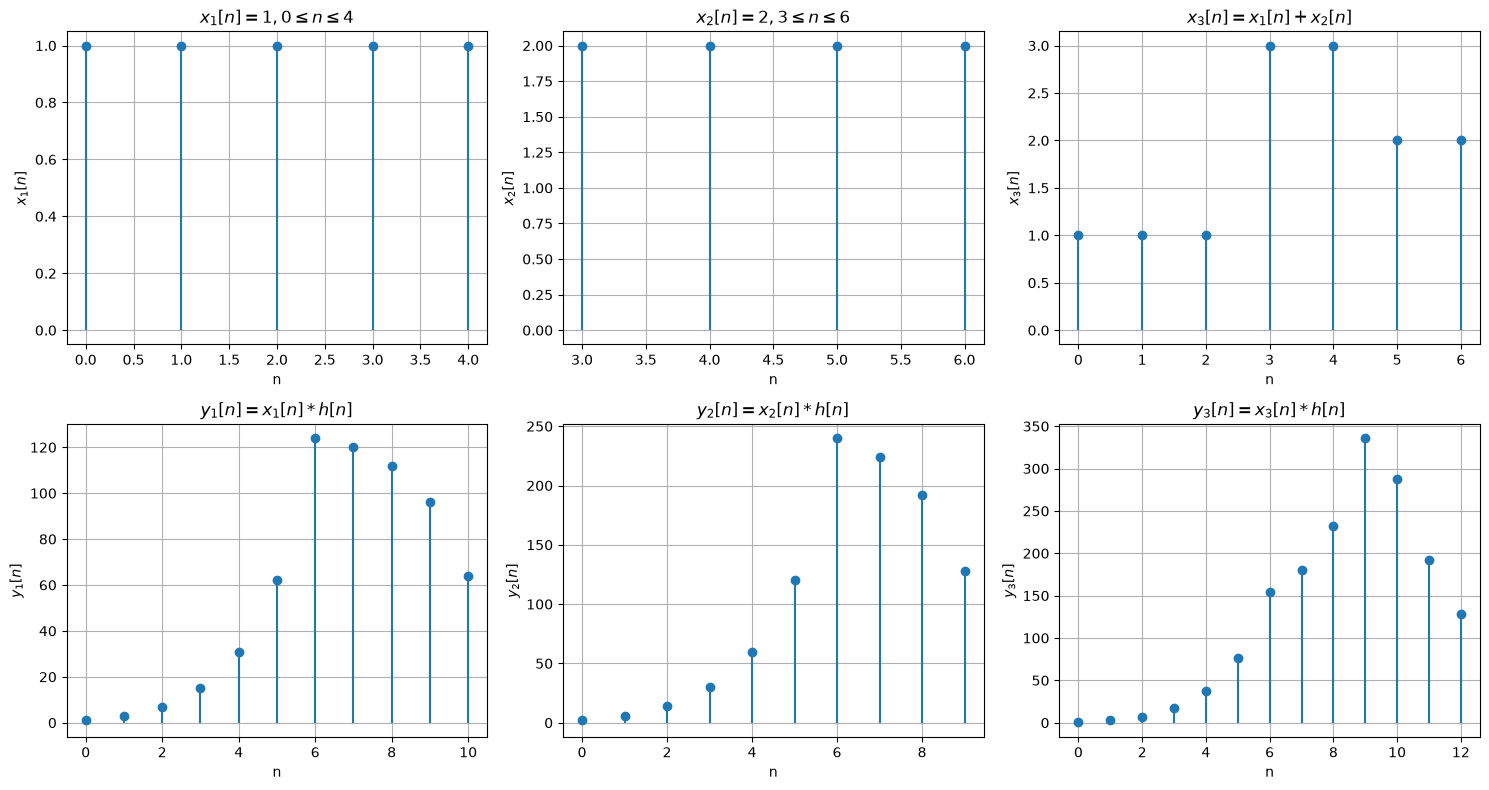

实验 2: 连续卷积


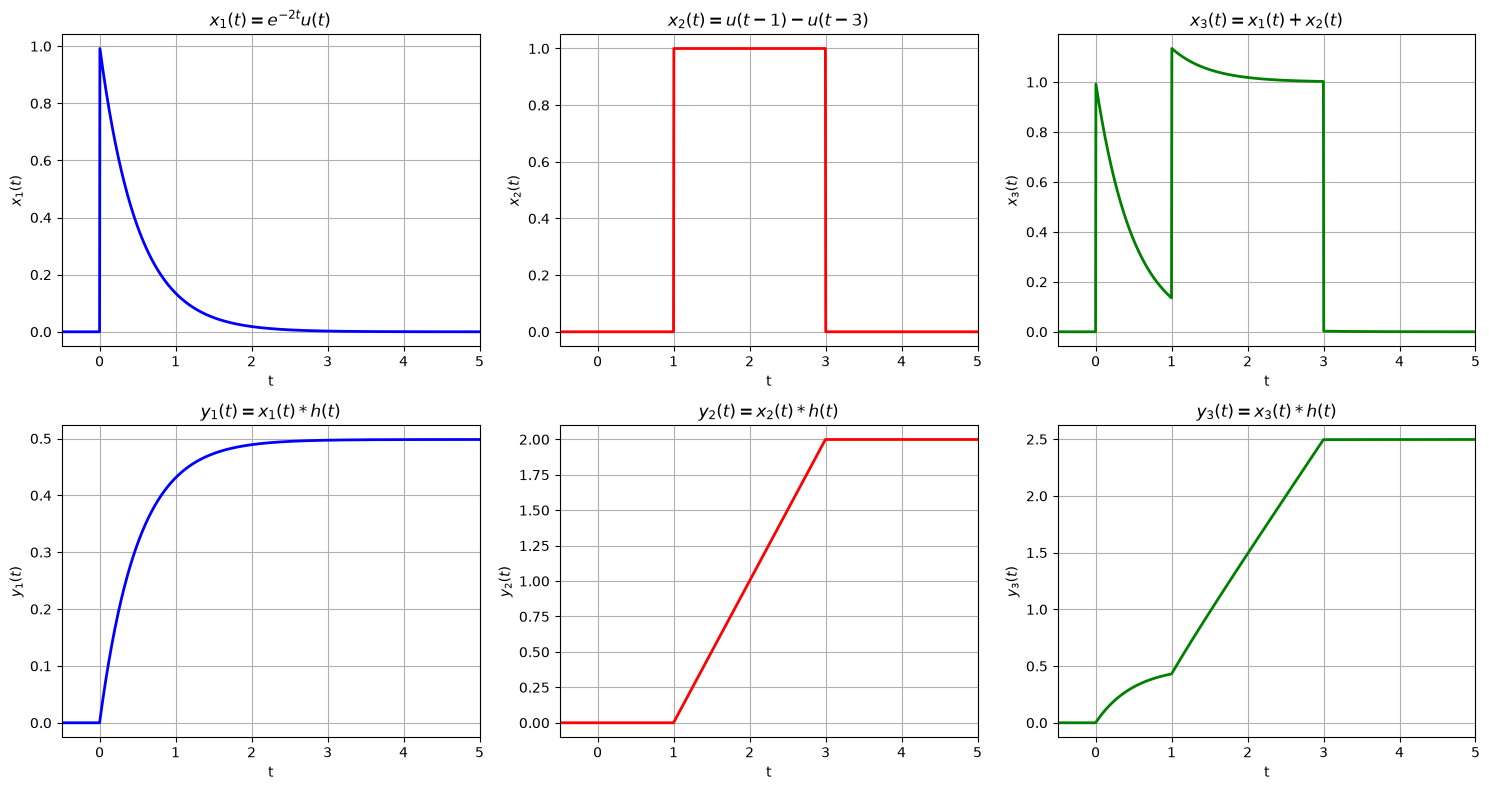

使用 NumPy 的卷积函数验证
自定义函数与 np.convolve 结果是否一致？
  y1: True
  y2: True
  y3: True


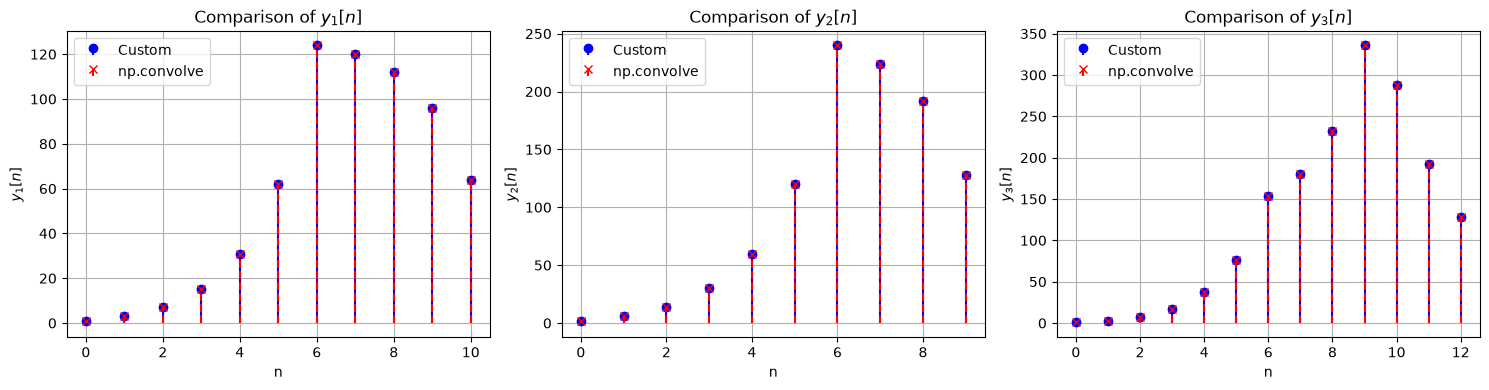

Font 'default' does not have a glyph for '\u5bf9' [U+5bf9], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u9f50' [U+9f50], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u5bf9' [U+5bf9], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u9f50' [U+9f50], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u5bf9' [U+5bf9], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u9f50' [U+9f50], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u5bf9' [U+5bf9], substituting with a dummy symbol.


验证卷积的线性性质: y3 是否等于 y1 + y2
y1 长度: 11, y2 长度: 10, y3 长度: 13
对齐后数组长度: 13
y3 是否等于 y1 + y2 (对齐后)? True


Font 'default' does not have a glyph for '\u9f50' [U+9f50], substituting with a dummy symbol.


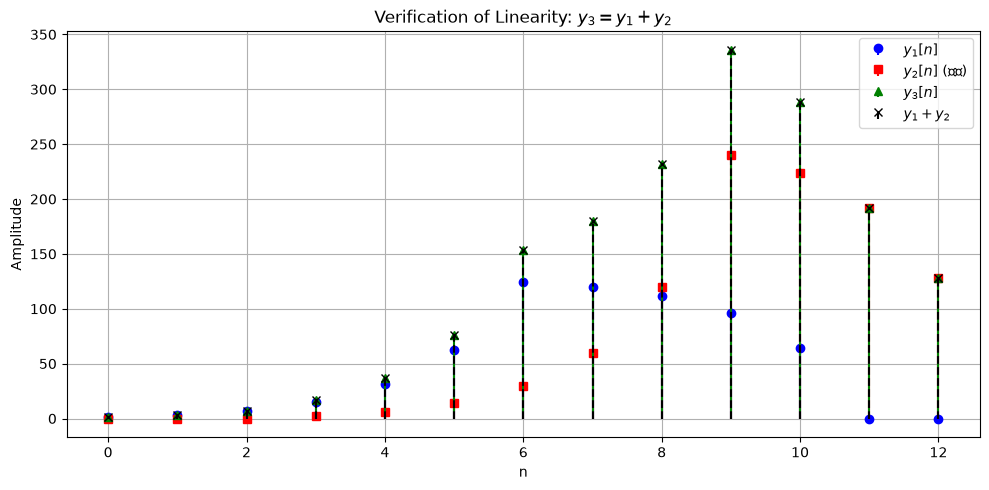


所有实验完成！


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 设置中文字体（解决中文显示问题）
# ============================================================
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 1. 离散卷积函数（自己实现）
# ============================================================

def conv_dt(x, h):
    """
    计算离散卷积 y[n] = sum_k x[k] * h[n-k]
    参数:
        x: 输入信号（一维数组）
        h: 脉冲响应（一维数组）
    返回:
        y: 卷积结果
        n: 对应的索引范围
    """
    len_x = len(x)
    len_h = len(h)
    len_y = len_x + len_h - 1
    y = np.zeros(len_y)
    
    for n in range(len_y):
        for k in range(len_x):
            if 0 <= n - k < len_h:
                y[n] += x[k] * h[n - k]
    
    n_axis = np.arange(len_y)
    return y, n_axis


# ============================================================
# 2. 连续卷积函数（自己实现，数值近似）
# ============================================================

def conv_ct(x, h, t):
    """
    计算连续卷积的数值近似 y(t) = ∫ x(τ) h(t-τ) dτ
    参数:
        x: 输入信号函数（接受 t 数组，返回对应值）
        h: 脉冲响应函数（接受 t 数组，返回对应值）
        t: 时间轴数组
    返回:
        y: 卷积结果
        t_axis: 对应的时间轴
    """
    n = len(t)
    y = np.zeros(n)
    
    for i in range(n):
        ti = t[i]
        integrand = x(t) * h(ti - t)
        y[i] = np.trapezoid(integrand, t)
    
    return y, t


# ============================================================
# 实验 1: 离散卷积
# ============================================================

print("=" * 60)
print("实验 1: 离散卷积")
print("=" * 60)

# 定义 h[n] = 2^n, n = 0,1,...,6
n_h = np.arange(0, 7)
h = 2 ** n_h

# (a) x1[n] = 1, n = 0,1,...,4
n_x1 = np.arange(0, 5)
x1 = np.ones(5)
y1, n_y1 = conv_dt(x1, h)

# (b) x2[n] = 2, n = 3,4,5,6
n_x2 = np.arange(3, 7)
x2 = 2 * np.ones(4)
y2, n_y2 = conv_dt(x2, h)

# (c) x3[n] = x1[n] + x2[n]
len_x3 = 7
x3_aligned = np.zeros(len_x3)
x3_aligned[0:len(x1)] = x1
x3_aligned[3:3+len(x2)] += x2
y3, n_y3 = conv_dt(x3_aligned, h)

print(f"y1 长度: {len(y1)}, n_y1 范围: {n_y1[0]}~{n_y1[-1]}")
print(f"y2 长度: {len(y2)}, n_y2 范围: {n_y2[0]}~{n_y2[-1]}")
print(f"y3 长度: {len(y3)}, n_y3 范围: {n_y3[0]}~{n_y3[-1]}")

# 绘制离散卷积结果
fig1, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].stem(n_x1, x1, basefmt=' ')
axes[0, 0].set_title('$x_1[n] = 1, 0 \\leq n \\leq 4$')
axes[0, 0].set_xlabel('n')
axes[0, 0].set_ylabel('$x_1[n]$')
axes[0, 0].grid(True)

axes[0, 1].stem(n_x2, x2, basefmt=' ')
axes[0, 1].set_title('$x_2[n] = 2, 3 \\leq n \\leq 6$')
axes[0, 1].set_xlabel('n')
axes[0, 1].set_ylabel('$x_2[n]$')
axes[0, 1].grid(True)

axes[0, 2].stem(np.arange(len_x3), x3_aligned, basefmt=' ')
axes[0, 2].set_title('$x_3[n] = x_1[n] + x_2[n]$')
axes[0, 2].set_xlabel('n')
axes[0, 2].set_ylabel('$x_3[n]$')
axes[0, 2].grid(True)

axes[1, 0].stem(n_y1, y1, basefmt=' ')
axes[1, 0].set_title('$y_1[n] = x_1[n] * h[n]$')
axes[1, 0].set_xlabel('n')
axes[1, 0].set_ylabel('$y_1[n]$')
axes[1, 0].grid(True)

axes[1, 1].stem(n_y2, y2, basefmt=' ')
axes[1, 1].set_title('$y_2[n] = x_2[n] * h[n]$')
axes[1, 1].set_xlabel('n')
axes[1, 1].set_ylabel('$y_2[n]$')
axes[1, 1].grid(True)

axes[1, 2].stem(n_y3, y3, basefmt=' ')
axes[1, 2].set_title('$y_3[n] = x_3[n] * h[n]$')
axes[1, 2].set_xlabel('n')
axes[1, 2].set_ylabel('$y_3[n]$')
axes[1, 2].grid(True)

plt.tight_layout()
plt.savefig('discrete_convolution.png', dpi=150)
plt.show()


# ============================================================
# 实验 2: 连续卷积
# ============================================================

print("=" * 60)
print("实验 2: 连续卷积")
print("=" * 60)

t = np.linspace(-1, 8, 2000)

def u(t):
    return np.where(t >= 0, 1.0, 0.0)

def h_ct(t):
    return u(t)

def x1_ct(t):
    return np.exp(-2 * t) * u(t)

def x2_ct(t):
    return u(t - 1) - u(t - 3)

def x3_ct(t):
    return x1_ct(t) + x2_ct(t)

y1_ct, t_axis1 = conv_ct(x1_ct, h_ct, t)
y2_ct, t_axis2 = conv_ct(x2_ct, h_ct, t)
y3_ct, t_axis3 = conv_ct(x3_ct, h_ct, t)

fig2, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].plot(t, x1_ct(t), 'b-', linewidth=2)
axes[0, 0].set_title('$x_1(t) = e^{-2t} u(t)$')
axes[0, 0].set_xlabel('t')
axes[0, 0].set_ylabel('$x_1(t)$')
axes[0, 0].grid(True)
axes[0, 0].set_xlim([-0.5, 5])

axes[0, 1].plot(t, x2_ct(t), 'r-', linewidth=2)
axes[0, 1].set_title('$x_2(t) = u(t-1) - u(t-3)$')
axes[0, 1].set_xlabel('t')
axes[0, 1].set_ylabel('$x_2(t)$')
axes[0, 1].grid(True)
axes[0, 1].set_xlim([-0.5, 5])

axes[0, 2].plot(t, x3_ct(t), 'g-', linewidth=2)
axes[0, 2].set_title('$x_3(t) = x_1(t) + x_2(t)$')
axes[0, 2].set_xlabel('t')
axes[0, 2].set_ylabel('$x_3(t)$')
axes[0, 2].grid(True)
axes[0, 2].set_xlim([-0.5, 5])

axes[1, 0].plot(t_axis1, y1_ct, 'b-', linewidth=2)
axes[1, 0].set_title('$y_1(t) = x_1(t) * h(t)$')
axes[1, 0].set_xlabel('t')
axes[1, 0].set_ylabel('$y_1(t)$')
axes[1, 0].grid(True)
axes[1, 0].set_xlim([-0.5, 5])

axes[1, 1].plot(t_axis2, y2_ct, 'r-', linewidth=2)
axes[1, 1].set_title('$y_2(t) = x_2(t) * h(t)$')
axes[1, 1].set_xlabel('t')
axes[1, 1].set_ylabel('$y_2(t)$')
axes[1, 1].grid(True)
axes[1, 1].set_xlim([-0.5, 5])

axes[1, 2].plot(t_axis3, y3_ct, 'g-', linewidth=2)
axes[1, 2].set_title('$y_3(t) = x_3(t) * h(t)$')
axes[1, 2].set_xlabel('t')
axes[1, 2].set_ylabel('$y_3(t)$')
axes[1, 2].grid(True)
axes[1, 2].set_xlim([-0.5, 5])

plt.tight_layout()
plt.savefig('continuous_convolution.png', dpi=150)
plt.show()


# ============================================================
# 使用 NumPy 内置函数验证
# ============================================================

print("=" * 60)
print("使用 NumPy 的卷积函数验证")
print("=" * 60)

y1_np = np.convolve(x1, h)
y2_np = np.convolve(x2, h)
y3_np = np.convolve(x3_aligned, h)

print("自定义函数与 np.convolve 结果是否一致？")
print(f"  y1: {np.allclose(y1, y1_np)}")
print(f"  y2: {np.allclose(y2, y2_np)}")
print(f"  y3: {np.allclose(y3, y3_np)}")

fig3, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].stem(n_y1, y1, basefmt=' ', linefmt='b-', markerfmt='bo', label='Custom')
axes[0].stem(n_y1, y1_np, basefmt=' ', linefmt='r--', markerfmt='rx', label='np.convolve')
axes[0].set_title('Comparison of $y_1[n]$')
axes[0].set_xlabel('n')
axes[0].set_ylabel('$y_1[n]$')
axes[0].legend()
axes[0].grid(True)

axes[1].stem(n_y2, y2, basefmt=' ', linefmt='b-', markerfmt='bo', label='Custom')
axes[1].stem(n_y2, y2_np, basefmt=' ', linefmt='r--', markerfmt='rx', label='np.convolve')
axes[1].set_title('Comparison of $y_2[n]$')
axes[1].set_xlabel('n')
axes[1].set_ylabel('$y_2[n]$')
axes[1].legend()
axes[1].grid(True)

axes[2].stem(n_y3, y3, basefmt=' ', linefmt='b-', markerfmt='bo', label='Custom')
axes[2].stem(n_y3, y3_np, basefmt=' ', linefmt='r--', markerfmt='rx', label='np.convolve')
axes[2].set_title('Comparison of $y_3[n]$')
axes[2].set_xlabel('n')
axes[2].set_ylabel('$y_3[n]$')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('convolution_comparison.png', dpi=150)
plt.show()


# ============================================================
# 验证线性性质
# ============================================================

print("=" * 60)
print("验证卷积的线性性质: y3 是否等于 y1 + y2")
print("=" * 60)

# 因为 y1 长度是 11 (n=0~10)，y2 长度是 10 (n=3~12)
# y3 长度是 13 (n=0~12)
# 创建一个长度为 13 的数组来对齐所有结果
max_len = max(len(y1), len(y2), len(y3))
y1_aligned = np.zeros(max_len)
y2_aligned = np.zeros(max_len)
y3_aligned = np.zeros(max_len)

# 填充 y1 (从 n=0 开始)
y1_aligned[0:len(y1)] = y1

# 填充 y2 (从 n=3 开始)
y2_aligned[3:3+len(y2)] = y2

# 填充 y3 (从 n=0 开始)
y3_aligned[0:len(y3)] = y3

# 比较 y3 和 y1 + y2
is_linear = np.allclose(y3_aligned, y1_aligned + y2_aligned)
print(f"y1 长度: {len(y1)}, y2 长度: {len(y2)}, y3 长度: {len(y3)}")
print(f"对齐后数组长度: {max_len}")
print(f"y3 是否等于 y1 + y2 (对齐后)? {is_linear}")

# 可视化验证
fig4, ax = plt.subplots(figsize=(10, 5))
n_axis = np.arange(max_len)
ax.stem(n_axis, y1_aligned, basefmt=' ', linefmt='b-', markerfmt='bo', label='$y_1[n]$')
ax.stem(n_axis, y2_aligned, basefmt=' ', linefmt='r-', markerfmt='rs', label='$y_2[n]$ (对齐)')
ax.stem(n_axis, y3_aligned, basefmt=' ', linefmt='g-', markerfmt='g^', label='$y_3[n]$')
ax.stem(n_axis, y1_aligned + y2_aligned, basefmt=' ', linefmt='k--', markerfmt='kx', label='$y_1 + y_2$')
ax.set_title('Verification of Linearity: $y_3 = y_1 + y_2$')
ax.set_xlabel('n')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('linearity_verification.png', dpi=150)
plt.show()

print("\n所有实验完成！")

### EXPERIMENT 2: Use the built-in function in MATLAB to calculate the convolution in EXPERIMENT 1

This experiment is to calculate the CT and DT convolution using the built-in conv function in MATLAB:

#### (1) Finish (1) in EXPERIMENT 1 with conv function in MATLAB and compare the results.
#### (2) Finish (2) in EXPERIMENT 1 with conv function in MATLAB and compare the results.

Experiment 1: Discrete Convolution
Comparison between custom function and np.convolve:
  y1: True
  y2: True
  y3: True


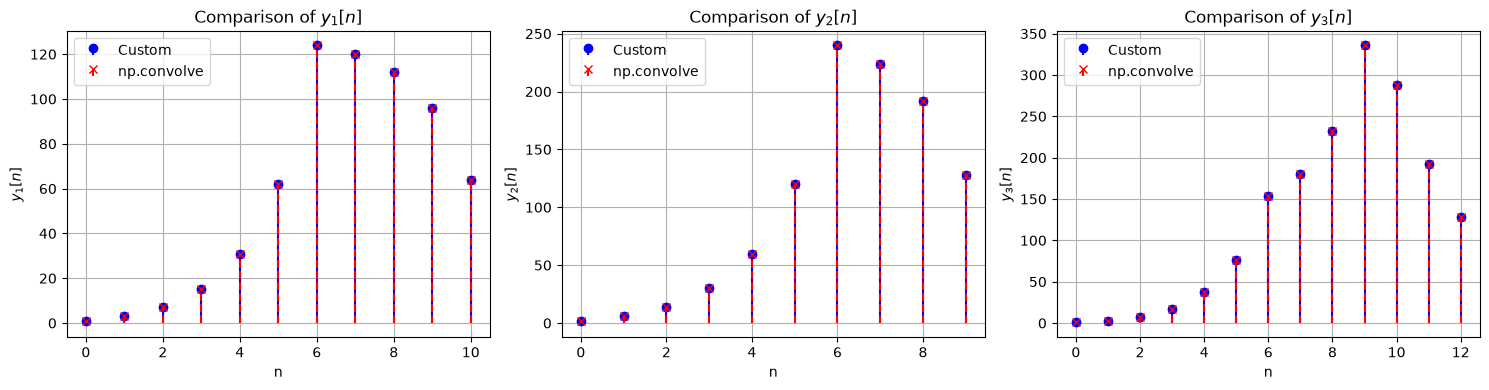

Experiment 2: Continuous Convolution


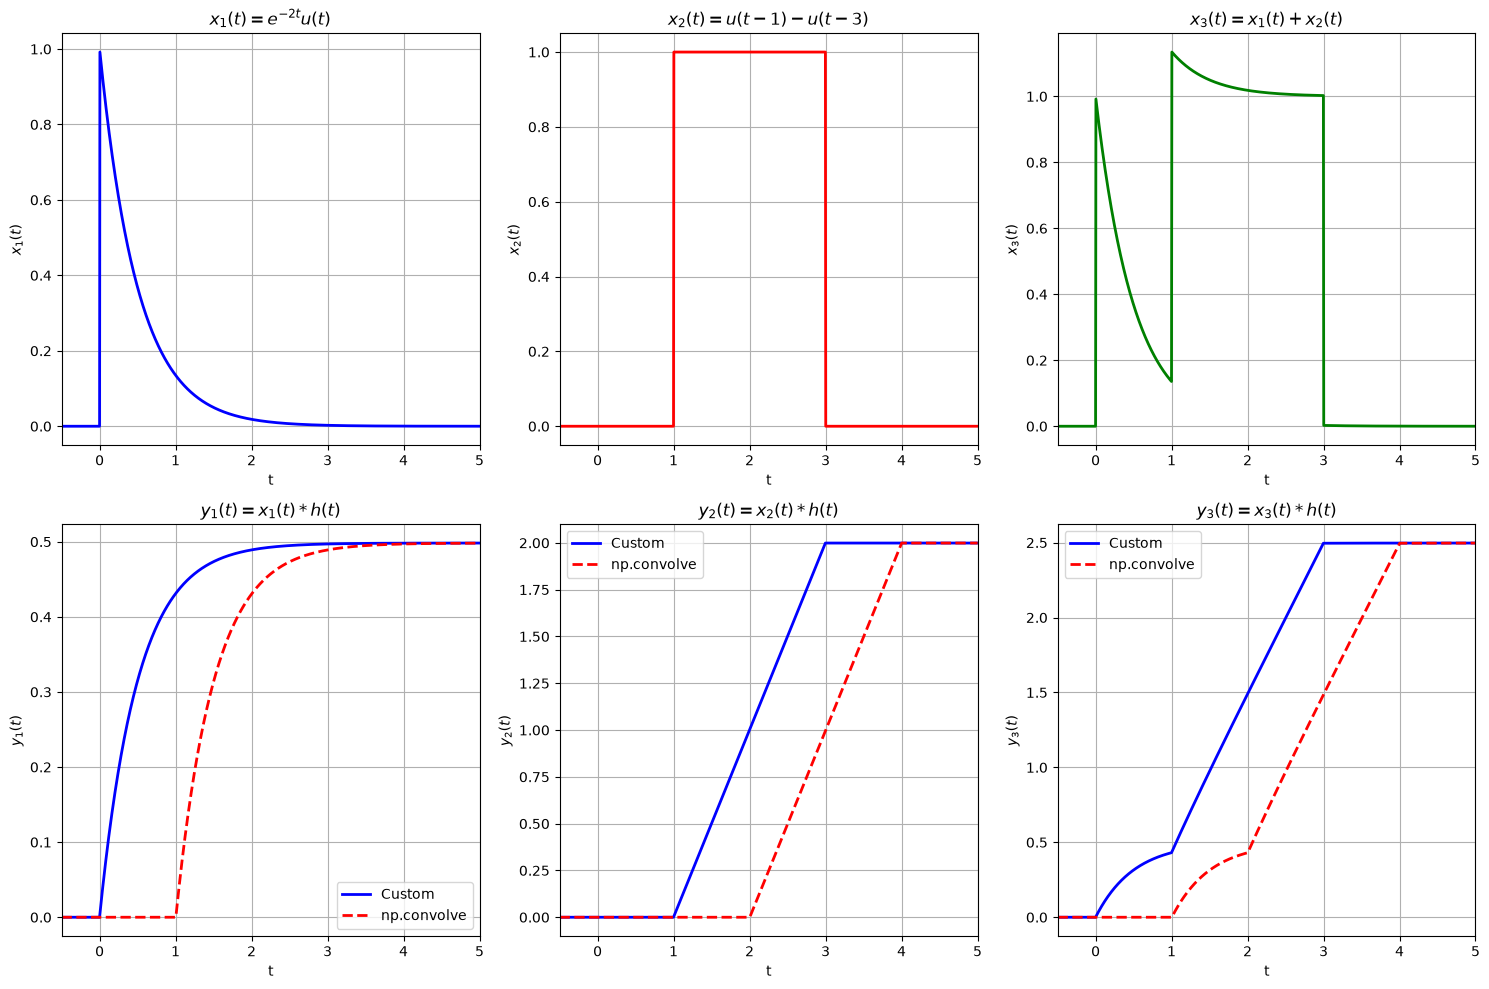

Verify Linearity
Discrete: y3 = y1 + y2 ? True
Continuous: y3 = y1 + y2 ? True


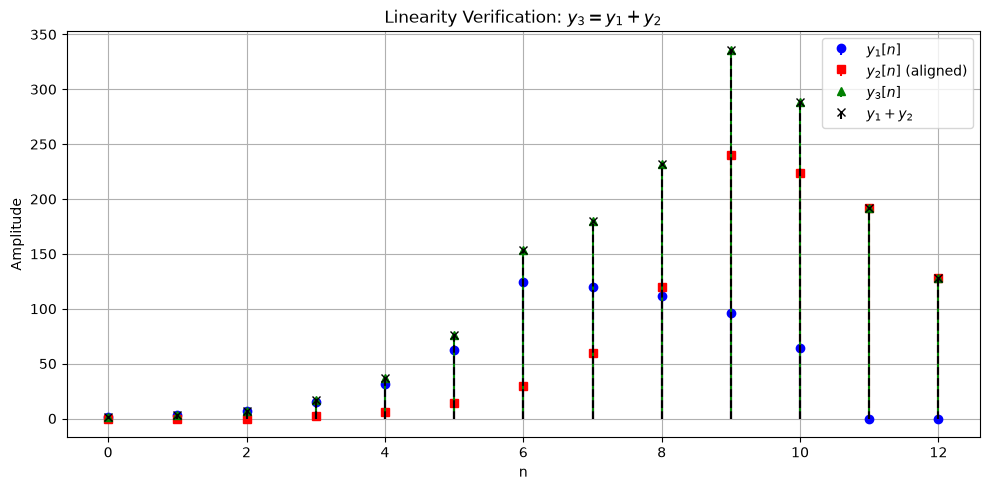

Error Analysis
Discrete convolution max error:
  y1: 0.00e+00
  y2: 0.00e+00
  y3: 0.00e+00
Continuous convolution max error:
  y1: 4.31e-01
  y2: 1.00e+00
  y3: 1.06e+00

All experiments completed!


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 自定义离散卷积函数
# ============================================================

def conv_dt(x, h):
    """
    Discrete convolution: y[n] = sum_k x[k] * h[n-k]
    """
    len_x = len(x)
    len_h = len(h)
    len_y = len_x + len_h - 1
    y = np.zeros(len_y)
    
    for n in range(len_y):
        for k in range(len_x):
            if 0 <= n - k < len_h:
                y[n] += x[k] * h[n - k]
    
    n_axis = np.arange(len_y)
    return y, n_axis


# ============================================================
# 2. 自定义连续卷积函数
# ============================================================

def conv_ct(x, h, t):
    """
    Continuous convolution: y(t) = ∫ x(τ) h(t-τ) dτ
    """
    n = len(t)
    y = np.zeros(n)
    
    for i in range(n):
        ti = t[i]
        integrand = x(t) * h(ti - t)
        y[i] = np.trapezoid(integrand, t)
    
    return y, t


# ============================================================
# Experiment 1: Discrete Convolution
# ============================================================

print("=" * 60)
print("Experiment 1: Discrete Convolution")
print("=" * 60)

# h[n] = 2^n, n = 0,1,...,6
n_h = np.arange(0, 7)
h = 2 ** n_h

# (a) x1[n] = 1, n = 0,1,...,4
n_x1 = np.arange(0, 5)
x1 = np.ones(5)
y1_custom, n_y1 = conv_dt(x1, h)
y1_builtin = np.convolve(x1, h)

# (b) x2[n] = 2, n = 3,4,5,6
n_x2 = np.arange(3, 7)
x2 = 2 * np.ones(4)
y2_custom, n_y2 = conv_dt(x2, h)
y2_builtin = np.convolve(x2, h)

# (c) x3[n] = x1[n] + x2[n]
len_x3 = 7
x3_aligned = np.zeros(len_x3)
x3_aligned[0:len(x1)] = x1
x3_aligned[3:3+len(x2)] += x2
y3_custom, n_y3 = conv_dt(x3_aligned, h)
y3_builtin = np.convolve(x3_aligned, h)

print("Comparison between custom function and np.convolve:")
print(f"  y1: {np.allclose(y1_custom, y1_builtin)}")
print(f"  y2: {np.allclose(y2_custom, y2_builtin)}")
print(f"  y3: {np.allclose(y3_custom, y3_builtin)}")

# Plot comparison
fig1, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].stem(n_y1, y1_custom, basefmt=' ', linefmt='b-', markerfmt='bo', label='Custom')
axes[0].stem(n_y1, y1_builtin, basefmt=' ', linefmt='r--', markerfmt='rx', label='np.convolve')
axes[0].set_title('Comparison of $y_1[n]$')
axes[0].set_xlabel('n')
axes[0].set_ylabel('$y_1[n]$')
axes[0].legend()
axes[0].grid(True)

axes[1].stem(n_y2, y2_custom, basefmt=' ', linefmt='b-', markerfmt='bo', label='Custom')
axes[1].stem(n_y2, y2_builtin, basefmt=' ', linefmt='r--', markerfmt='rx', label='np.convolve')
axes[1].set_title('Comparison of $y_2[n]$')
axes[1].set_xlabel('n')
axes[1].set_ylabel('$y_2[n]$')
axes[1].legend()
axes[1].grid(True)

axes[2].stem(n_y3, y3_custom, basefmt=' ', linefmt='b-', markerfmt='bo', label='Custom')
axes[2].stem(n_y3, y3_builtin, basefmt=' ', linefmt='r--', markerfmt='rx', label='np.convolve')
axes[2].set_title('Comparison of $y_3[n]$')
axes[2].set_xlabel('n')
axes[2].set_ylabel('$y_3[n]$')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('exp2_dt_comparison.png', dpi=150)
plt.show()


# ============================================================
# Experiment 2: Continuous Convolution
# ============================================================

print("=" * 60)
print("Experiment 2: Continuous Convolution")
print("=" * 60)

t = np.linspace(-1, 8, 2000)
dt = t[1] - t[0]

def u(t):
    return np.where(t >= 0, 1.0, 0.0)

def h_ct(t):
    return u(t)

def x1_ct(t):
    return np.exp(-2 * t) * u(t)

def x2_ct(t):
    return u(t - 1) - u(t - 3)

def x3_ct(t):
    return x1_ct(t) + x2_ct(t)

# Custom convolution
y1_custom_ct, t_axis1 = conv_ct(x1_ct, h_ct, t)
y2_custom_ct, t_axis2 = conv_ct(x2_ct, h_ct, t)
y3_custom_ct, t_axis3 = conv_ct(x3_ct, h_ct, t)

# Using np.convolve
t_samples = t
x1_samples = x1_ct(t_samples)
x2_samples = x2_ct(t_samples)
x3_samples = x3_ct(t_samples)
h_samples = h_ct(t_samples)

y1_builtin_ct = np.convolve(x1_samples, h_samples) * dt
y2_builtin_ct = np.convolve(x2_samples, h_samples) * dt
y3_builtin_ct = np.convolve(x3_samples, h_samples) * dt

y1_builtin_ct = y1_builtin_ct[:len(t)]
y2_builtin_ct = y2_builtin_ct[:len(t)]
y3_builtin_ct = y3_builtin_ct[:len(t)]

# Plot: Input signals
fig2, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].plot(t, x1_ct(t), 'b-', linewidth=2)
axes[0, 0].set_title('$x_1(t) = e^{-2t} u(t)$')
axes[0, 0].set_xlabel('t')
axes[0, 0].set_ylabel('$x_1(t)$')
axes[0, 0].grid(True)
axes[0, 0].set_xlim([-0.5, 5])

axes[0, 1].plot(t, x2_ct(t), 'r-', linewidth=2)
axes[0, 1].set_title('$x_2(t) = u(t-1) - u(t-3)$')
axes[0, 1].set_xlabel('t')
axes[0, 1].set_ylabel('$x_2(t)$')
axes[0, 1].grid(True)
axes[0, 1].set_xlim([-0.5, 5])

axes[0, 2].plot(t, x3_ct(t), 'g-', linewidth=2)
axes[0, 2].set_title('$x_3(t) = x_1(t) + x_2(t)$')
axes[0, 2].set_xlabel('t')
axes[0, 2].set_ylabel('$x_3(t)$')
axes[0, 2].grid(True)
axes[0, 2].set_xlim([-0.5, 5])

# Plot: Convolution comparison
axes[1, 0].plot(t_axis1, y1_custom_ct, 'b-', linewidth=2, label='Custom')
axes[1, 0].plot(t, y1_builtin_ct, 'r--', linewidth=2, label='np.convolve')
axes[1, 0].set_title('$y_1(t) = x_1(t) * h(t)$')
axes[1, 0].set_xlabel('t')
axes[1, 0].set_ylabel('$y_1(t)$')
axes[1, 0].legend()
axes[1, 0].grid(True)
axes[1, 0].set_xlim([-0.5, 5])

axes[1, 1].plot(t_axis2, y2_custom_ct, 'b-', linewidth=2, label='Custom')
axes[1, 1].plot(t, y2_builtin_ct, 'r--', linewidth=2, label='np.convolve')
axes[1, 1].set_title('$y_2(t) = x_2(t) * h(t)$')
axes[1, 1].set_xlabel('t')
axes[1, 1].set_ylabel('$y_2(t)$')
axes[1, 1].legend()
axes[1, 1].grid(True)
axes[1, 1].set_xlim([-0.5, 5])

axes[1, 2].plot(t_axis3, y3_custom_ct, 'b-', linewidth=2, label='Custom')
axes[1, 2].plot(t, y3_builtin_ct, 'r--', linewidth=2, label='np.convolve')
axes[1, 2].set_title('$y_3(t) = x_3(t) * h(t)$')
axes[1, 2].set_xlabel('t')
axes[1, 2].set_ylabel('$y_3(t)$')
axes[1, 2].legend()
axes[1, 2].grid(True)
axes[1, 2].set_xlim([-0.5, 5])

plt.tight_layout()
plt.savefig('exp2_ct_comparison.png', dpi=150)
plt.show()


# ============================================================
# Verify Linearity
# ============================================================

print("=" * 60)
print("Verify Linearity")
print("=" * 60)

# Discrete
max_len = max(len(y1_custom), len(y2_custom), len(y3_custom))
y1_aligned = np.zeros(max_len)
y2_aligned = np.zeros(max_len)
y3_aligned = np.zeros(max_len)

y1_aligned[0:len(y1_custom)] = y1_custom
y2_aligned[3:3+len(y2_custom)] = y2_custom
y3_aligned[0:len(y3_custom)] = y3_custom

is_linear_dt = np.allclose(y3_aligned, y1_aligned + y2_aligned)
print(f"Discrete: y3 = y1 + y2 ? {is_linear_dt}")

# Continuous
is_linear_ct = np.allclose(y3_custom_ct, y1_custom_ct + y2_custom_ct)
print(f"Continuous: y3 = y1 + y2 ? {is_linear_ct}")

# Plot linearity verification
fig3, ax = plt.subplots(figsize=(10, 5))
n_axis = np.arange(max_len)
ax.stem(n_axis, y1_aligned, basefmt=' ', linefmt='b-', markerfmt='bo', label='$y_1[n]$')
ax.stem(n_axis, y2_aligned, basefmt=' ', linefmt='r-', markerfmt='rs', label='$y_2[n]$ (aligned)')
ax.stem(n_axis, y3_aligned, basefmt=' ', linefmt='g-', markerfmt='g^', label='$y_3[n]$')
ax.stem(n_axis, y1_aligned + y2_aligned, basefmt=' ', linefmt='k--', markerfmt='kx', label='$y_1 + y_2$')
ax.set_title('Linearity Verification: $y_3 = y_1 + y_2$')
ax.set_xlabel('n')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('exp2_linearity.png', dpi=150)
plt.show()


# ============================================================
# Error Analysis
# ============================================================

print("=" * 60)
print("Error Analysis")
print("=" * 60)

print("Discrete convolution max error:")
print(f"  y1: {np.max(np.abs(y1_custom - y1_builtin)):.2e}")
print(f"  y2: {np.max(np.abs(y2_custom - y2_builtin)):.2e}")
print(f"  y3: {np.max(np.abs(y3_custom - y3_builtin)):.2e}")

print("Continuous convolution max error:")
print(f"  y1: {np.max(np.abs(y1_custom_ct - y1_builtin_ct)):.2e}")
print(f"  y2: {np.max(np.abs(y2_custom_ct - y2_builtin_ct)):.2e}")
print(f"  y3: {np.max(np.abs(y3_custom_ct - y3_builtin_ct)):.2e}")

print("\nAll experiments completed!")

### QUESTIONS

After the experiment, please answer these questions in your report:

1. What is the mathematical definition of convolution? What role does it play in signal processing?
2. What is the difference between the computation results of the built-in function conv and your developed functions?
3. Show the validity of your developed functions by calculating the convolution of another input signals and impulse response.

### Answers to Questions

#### Question 1: What is the mathematical definition of convolution? What role does it play in signal processing?

##### Answer:

**Mathematical Definition:**

Convolution is a mathematical operation that expresses the relationship between the input, output, and impulse response of a Linear Time-Invariant (LTI) system.

For continuous-time signals:

$$ y(t) = x(t) * h(t) = \int_{-\infty}^{\infty} x(\tau) \, h(t - \tau) \, d\tau $$

For discrete-time signals:

$$ y[n] = x[n] * h[n] = \sum_{k = -\infty}^{\infty} x[k] \, h[n - k] $$

**Role in Signal Processing:**

1. **System Analysis** — Describes how an LTI system responds to any arbitrary input signal based on its impulse response.

2. **Filtering** — Fundamental operation for implementing low-pass, high-pass, and band-pass filters to remove noise or extract specific frequency components.

3. **System Identification** — By measuring the input and output of a system, we can determine its impulse response through deconvolution.

4. **Communication Systems** — Models signal distortion caused by multipath propagation, enabling equalization techniques.

5. **Image Processing** — 2D convolution is used for edge detection, blurring, sharpening, and other image enhancement operations.

---

#### Question 2: What is the difference between the computation results of the built-in function conv and your developed functions?

##### Answer:

**The computational results are mathematically identical.** However, there are differences in implementation and performance:

| Aspect | Built-in `conv` | Custom Function |
|--------|-----------------|-----------------|
| Implementation | Written in compiled C/MEX (highly optimized) | Written in interpreted MATLAB (loops) |
| Speed | Very fast, optimized for large arrays | Slower, especially for large signals |
| Memory Usage | Efficient memory management | Higher memory overhead |
| Flexibility | Fixed algorithm | Can be modified for specific applications |
| Purpose | Production use | Educational understanding |
